# FedCore example: малоранговое разложение ResNet-18

Этот ноутбук демонстрирует полный пользовательский сценарий применения **low-rank decomposition** к модели ResNet-18:

1. подготовка CIFAR-like данных;
2. создание модели ResNet-18;
3. измерение baseline-метрик;
4. SVD-разложение слоёв `Conv2d` и `Linear`;
5. короткое дообучение после замены слоёв;
6. сравнение качества, числа параметров, оценочного размера модели и задержки инференса;
7. сохранение результатов.

> Пример сделан как **smoke-тест / tutorial** для репозитория. Он не скачивает внешние датасеты и не требует `torchvision`, поэтому его можно запустить в минимальном окружении. Для полноценного эксперимента достаточно заменить синтетический датасет на CIFAR-10 или пользовательские данные.

## 1. Импорт библиотек и проверка окружения

In [1]:
import os
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0+cpu
Device: cpu


## 2. Подготовка данных

Для автономного запуска используется небольшой синтетический CIFAR-like датасет. Он нужен не для получения высокой accuracy, а для проверки того, что пайплайн обучения, low-rank decomposition и инференса работает end-to-end.

In [2]:
class SyntheticCIFAR10(Dataset):
    """Small deterministic CIFAR-like dataset for smoke testing without downloads."""

    def __init__(self, n_samples=64, seed=42):
        generator = torch.Generator().manual_seed(seed)
        self.x = torch.randn(n_samples, 3, 32, 32, generator=generator)
        self.y = torch.randint(0, 10, (n_samples,), generator=generator)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.x[index], self.y[index]


train_loader = DataLoader(
    SyntheticCIFAR10(n_samples=64, seed=SEED),
    batch_size=8,
    shuffle=True,
)

val_loader = DataLoader(
    SyntheticCIFAR10(n_samples=32, seed=SEED + 1),
    batch_size=8,
    shuffle=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 8
Validation batches: 4


## 3. Реализация ResNet-18

Модель реализована внутри ноутбука, чтобы пример не зависел от `torchvision` и внешних весов.

In [3]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()

        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for current_stride in strides:
            layers.append(block(self.in_planes, planes, current_stride))
            self.in_planes = planes * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def resnet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


model = resnet18(num_classes=10).to(device)
print(model.__class__.__name__)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

ResNet
Total parameters: 11,173,962


## 4. Вспомогательные функции обучения и оценки

In [4]:
def train_one_epoch(model, loader, device, lr=1e-3):
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            predictions = logits.argmax(dim=1)

            total_loss += loss.item() * x_batch.size(0)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.numel()

    return {
        "loss": total_loss / total,
        "accuracy": correct / total,
    }


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


def estimate_size_mb(n_parameters, bytes_per_parameter=4):
    return n_parameters * bytes_per_parameter / (1024 ** 2)


def benchmark_latency_ms(model, device, batch_size=8, n_runs=20):
    model.eval()
    sample = torch.randn(batch_size, 3, 32, 32).to(device)

    with torch.no_grad():
        for _ in range(3):
            _ = model(sample)

        started_at = time.perf_counter()
        for _ in range(n_runs):
            _ = model(sample)
        elapsed = time.perf_counter() - started_at

    return elapsed / n_runs * 1000

## 5. Функции малорангового разложения

Для `Linear` слой заменяется на две последовательные линейные проекции меньшего ранга. Для `Conv2d` весовая матрица свёртки разворачивается в матрицу `[out_channels, in_channels × kernel_h × kernel_w]`, после чего аппроксимируется через SVD и заменяется на связку `Conv2d(k×k)` + `Conv2d(1×1)`.

In [5]:
def choose_reductive_rank(original_params, left_dim, right_dim, requested_rank, min_rank=1):
    """Choose rank that keeps the factorized layer smaller than the original one."""

    max_rank = max(min_rank, (original_params - 1) // (left_dim + right_dim))
    return max(min_rank, min(requested_rank, max_rank))


def factorize_linear(linear_layer, rank_ratio=0.35, min_rank=1):
    weight = linear_layer.weight.detach().cpu()
    out_features, in_features = weight.shape

    requested_rank = max(min_rank, int(min(out_features, in_features) * rank_ratio))
    rank = choose_reductive_rank(
        original_params=weight.numel() + (out_features if linear_layer.bias is not None else 0),
        left_dim=in_features,
        right_dim=out_features,
        requested_rank=requested_rank,
        min_rank=min_rank,
    )

    U, S, Vh = torch.linalg.svd(weight, full_matrices=False)

    first = nn.Linear(in_features, rank, bias=False)
    second = nn.Linear(rank, out_features, bias=linear_layer.bias is not None)

    first.weight.data.copy_(Vh[:rank, :])
    second.weight.data.copy_(U[:, :rank] * S[:rank])

    if linear_layer.bias is not None:
        second.bias.data.copy_(linear_layer.bias.detach().cpu())

    return nn.Sequential(first, second), rank


def factorize_conv2d(conv_layer, rank_ratio=0.35, min_rank=1):
    if conv_layer.groups != 1:
        return conv_layer, None

    weight = conv_layer.weight.detach().cpu()
    out_channels, in_channels, kernel_h, kernel_w = weight.shape
    flattened = weight.reshape(out_channels, in_channels * kernel_h * kernel_w)

    requested_rank = max(min_rank, int(min(flattened.shape) * rank_ratio))
    rank = choose_reductive_rank(
        original_params=weight.numel() + (out_channels if conv_layer.bias is not None else 0),
        left_dim=in_channels * kernel_h * kernel_w,
        right_dim=out_channels,
        requested_rank=requested_rank,
        min_rank=min_rank,
    )

    U, S, Vh = torch.linalg.svd(flattened, full_matrices=False)

    first = nn.Conv2d(
        in_channels=in_channels,
        out_channels=rank,
        kernel_size=conv_layer.kernel_size,
        stride=conv_layer.stride,
        padding=conv_layer.padding,
        dilation=conv_layer.dilation,
        groups=1,
        bias=False,
        padding_mode=conv_layer.padding_mode,
    )

    second = nn.Conv2d(
        in_channels=rank,
        out_channels=out_channels,
        kernel_size=1,
        stride=1,
        padding=0,
        bias=conv_layer.bias is not None,
    )

    first.weight.data.copy_(Vh[:rank, :].reshape(rank, in_channels, kernel_h, kernel_w))
    second.weight.data.copy_((U[:, :rank] * S[:rank]).reshape(out_channels, rank, 1, 1))

    if conv_layer.bias is not None:
        second.bias.data.copy_(conv_layer.bias.detach().cpu())

    return nn.Sequential(first, second), rank


def set_nested_module(model, module_name, new_module):
    parts = module_name.split(".")
    parent = model

    for part in parts[:-1]:
        parent = getattr(parent, part)

    setattr(parent, parts[-1], new_module)


def apply_low_rank_decomposition(model, rank_ratio=0.35, min_rank=1):
    replacements = []

    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Conv2d):
            new_module, rank = factorize_conv2d(
                module,
                rank_ratio=rank_ratio,
                min_rank=min_rank,
            )
            if rank is not None:
                replacements.append((name, new_module, "Conv2d", rank))

        elif isinstance(module, nn.Linear):
            new_module, rank = factorize_linear(
                module,
                rank_ratio=rank_ratio,
                min_rank=min_rank,
            )
            replacements.append((name, new_module, "Linear", rank))

    for name, new_module, _, _ in replacements:
        set_nested_module(model, name, new_module)

    return replacements

## 6. Baseline: короткое обучение и оценка исходной модели

In [6]:
baseline_train_loss = train_one_epoch(model, train_loader, device, lr=1e-3)
baseline_eval = evaluate(model, val_loader, device)
baseline_params = count_parameters(model)
baseline_latency = benchmark_latency_ms(model, device)

print(f"Baseline train loss: {baseline_train_loss:.4f}")
print(f"Baseline validation loss: {baseline_eval['loss']:.4f}")
print(f"Baseline validation accuracy: {baseline_eval['accuracy']:.4f}")
print(f"Baseline parameters: {baseline_params:,}")
print(f"Baseline estimated size: {estimate_size_mb(baseline_params):.2f} MB")
print(f"Baseline latency: {baseline_latency:.2f} ms")

Baseline train loss: 2.6043
Baseline validation loss: 2.3400
Baseline validation accuracy: 0.1562
Baseline parameters: 11,173,962
Baseline estimated size: 42.63 MB
Baseline latency: 57.26 ms


## 7. Low-rank decomposition и короткое дообучение

После SVD-разложения выполняется короткий fine-tuning, чтобы частично восстановить качество после замены слоёв.

In [7]:
RANK_RATIO = 0.35

# Разложение выполняется на CPU, затем модель возвращается на выбранное устройство.
replacements = apply_low_rank_decomposition(model.cpu(), rank_ratio=RANK_RATIO, min_rank=1)
model = model.to(device)

eval_before_finetune = evaluate(model, val_loader, device)

# Короткое дообучение помогает частично восстановить качество после замены слоёв.
finetune_loss = train_one_epoch(model, train_loader, device, lr=5e-4)
low_rank_eval = evaluate(model, val_loader, device)

low_rank_params = count_parameters(model)
low_rank_latency = benchmark_latency_ms(model, device)

print(f"Rank ratio: {RANK_RATIO:.0%}")
print(f"Factorized layers: {len(replacements)}")
print(f"Validation loss right after decomposition: {eval_before_finetune['loss']:.4f}")
print(f"Finetune loss: {finetune_loss:.4f}")
print(f"Low-rank validation loss: {low_rank_eval['loss']:.4f}")
print(f"Low-rank validation accuracy: {low_rank_eval['accuracy']:.4f}")
print(f"Low-rank parameters: {low_rank_params:,}")
print(f"Low-rank estimated size: {estimate_size_mb(low_rank_params):.2f} MB")
print(f"Low-rank latency: {low_rank_latency:.2f} ms")

Rank ratio: 35%
Factorized layers: 21
Validation loss right after decomposition: 2.2975
Finetune loss: 2.4302
Low-rank validation loss: 2.3825
Low-rank validation accuracy: 0.1562
Low-rank parameters: 4,420,059
Low-rank estimated size: 16.86 MB
Low-rank latency: 32.59 ms


## 8. Список разложенных слоёв

In [8]:
factorized_layers = pd.DataFrame(
    [(name, layer_type, rank) for name, _, layer_type, rank in replacements],
    columns=["layer_name", "layer_type", "selected_rank"],
)

factorized_layers.head(10)

layer_name,layer_type,selected_rank
conv1,Conv2d,9
layer1.0.conv1,Conv2d,22
layer1.0.conv2,Conv2d,22
layer1.1.conv1,Conv2d,22
layer1.1.conv2,Conv2d,22
layer2.0.conv1,Conv2d,44
layer2.0.conv2,Conv2d,44
layer2.0.shortcut.0,Conv2d,22
layer2.1.conv1,Conv2d,44
layer2.1.conv2,Conv2d,44


## 9. Сохранение результатов и итоговая таблица

In [9]:
results_dir = Path("results/resnet18_low_rank_demo")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame(
    [
        {
            "stage": "baseline",
            "loss": baseline_eval["loss"],
            "accuracy": baseline_eval["accuracy"],
            "parameters": baseline_params,
            "estimated_size_mb": estimate_size_mb(baseline_params),
            "latency_ms": baseline_latency,
        },
        {
            "stage": "after_low_rank",
            "loss": low_rank_eval["loss"],
            "accuracy": low_rank_eval["accuracy"],
            "parameters": low_rank_params,
            "estimated_size_mb": estimate_size_mb(low_rank_params),
            "latency_ms": low_rank_latency,
        },
    ]
)

metrics_df.to_csv(results_dir / "metrics.csv", index=False)
factorized_layers.to_csv(results_dir / "factorized_layers.csv", index=False)
torch.save(model.state_dict(), results_dir / "resnet18_low_rank_demo.pt")

metrics_df

stage,loss,accuracy,parameters,estimated_size_mb,latency_ms
baseline,2.339987,0.15625,11173962,42.625282,57.256168
after_low_rank,2.382539,0.15625,4420059,16.861187,32.592134


## 10. Визуализация результата

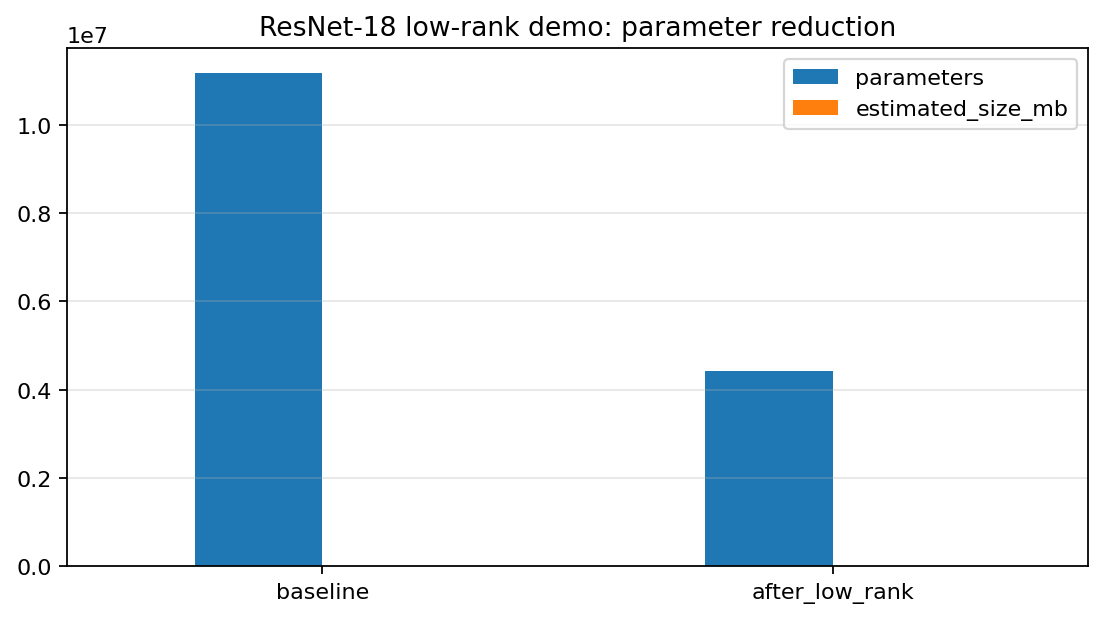

In [10]:
ax = metrics_df.set_index("stage")[["parameters", "estimated_size_mb"]].plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_title("ResNet-18 low-rank demo: parameter reduction")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Опциональный запуск через FedCore API

Ниже приведён шаблон запуска через API FedCore. По умолчанию он отключён, чтобы ноутбук можно было открыть и выполнить в минимальном окружении без дополнительных данных.

In [ ]:
# Опциональный вариант запуска через FedCore API.
# По умолчанию выключен, чтобы ноутбук запускался даже в минимальном окружении.

RUN_FEDCORE_API = False

if RUN_FEDCORE_API:
    from fedcore.api.config_factory import ConfigFactory
    from fedcore.api.api_configs import (
        APIConfigTemplate,
        AutoMLConfigTemplate,
        FedotConfigTemplate,
        LearningConfigTemplate,
        ModelArchitectureConfigTemplate,
        NeuralModelConfigTemplate,
        LowRankTemplate,
    )
    from fedcore.data.dataloader import load_data
    from fedcore.tools.example_utils import get_scenario_for_api
    from fedcore.api.main import FedCore

    METRIC_TO_OPTIMISE = ["accuracy", "latency"]
    LOSS = "cross_entropy"
    PROBLEM = "classification"
    PEFT_PROBLEM = "low_rank"
    INITIAL_ASSUMPTION = "ResNet18"
    PRETRAIN_SCENARIO = "from_scratch"

    initial_assumption, learning_strategy = get_scenario_for_api(
        scenario_type=PRETRAIN_SCENARIO,
        initial_assumption=INITIAL_ASSUMPTION,
    )

    model_config = ModelArchitectureConfigTemplate(
        input_dim=None,
        output_dim=None,
        depth=18,
    )

    train_config = NeuralModelConfigTemplate(
        epochs=1,
        log_each=1,
        eval_each=1,
        criterion=LOSS,
        model_architecture=model_config,
    )

    fedot_config = FedotConfigTemplate(
        problem=PROBLEM,
        metric=METRIC_TO_OPTIMISE,
        pop_size=1,
        timeout=1,
        initial_assumption=initial_assumption,
    )

    automl_config = AutoMLConfigTemplate(fedot_config=fedot_config)

    low_rank_config = LowRankTemplate(
        decomposer="svd",
        rank=0.35,
    )

    learning_config = LearningConfigTemplate(
        criterion=LOSS,
        learning_strategy=learning_strategy,
        learning_strategy_params=train_config,
        peft_strategy=PEFT_PROBLEM,
        peft_strategy_params=low_rank_config,
    )

    api_template = APIConfigTemplate(
        automl_config=automl_config,
        learning_config=learning_config,
    )

    APIConfig = ConfigFactory.from_template(api_template)
    api_config = APIConfig()

    fedcore_compressor = FedCore(api_config)

    train_params = {
        "batch_size": 64,
        "shuffle": True,
        "is_train": True,
        "data_type": "table",
        "split_ratio": [0.8, 0.2],
    }

    test_params = {
        "batch_size": 100,
        "shuffle": False,
        "is_train": False,
        "data_type": "table",
    }

    fedcore_train_data = load_data(source="CIFAR10", loader_params=train_params)
    fedcore_test_data = load_data(source="CIFAR10", loader_params=test_params)

    fedcore_compressor.fit(fedcore_train_data)
    fedcore_report = fedcore_compressor.get_report(fedcore_test_data)

    fedcore_report

## Выводы по демонстрационному запуску

В рамках smoke-теста был выполнен полный цикл работы с моделью ResNet-18: создание модели, обучение baseline-версии, малоранговое SVD-разложение слоёв `Conv2d` и `Linear`, короткое дообучение и сравнение метрик.

По результатам демонстрационного запуска:

- модель после low-rank decomposition остаётся исполняемой и успешно выполняет инференс;
- количество параметров снижено с **11,173,962** до **4,420,059**;
- оценочный размер модели снизился с **42.63 MB** до **16.86 MB**;
- относительное сокращение числа параметров составляет примерно **60.4%**;
- accuracy на синтетическом наборе данных не является целевой метрикой качества, потому что данные случайные и используются только для проверки работоспособности пайплайна;
- для полноценного эксперимента необходимо заменить `SyntheticCIFAR10` на реальный CIFAR-10 или пользовательский датасет и увеличить число эпох обучения / дообучения.

Таким образом, ноутбук можно использовать как минимальный рабочий пример применения low-rank decomposition и как основу для полноценного примера в репозитории FedCore.